# [실습 프로젝트] 스타벅스 마케팅 데이터 분석  
## 1. 문제의식 및 분석 관점 정리

---

## 1) 프로젝트 배경

여러분은 스타벅스 마케팅 데이터 분석가라고 가정합니다.  
이번 프로젝트의 목적은 **고객에게 발송된 프로모션(offer)이 실제로 고객 반응과 거래로 이어졌는지**를 데이터로 확인하고,  
그 결과를 **Streamlit 대시보드**로 직관적으로 전달하는 것입니다.

이 데이터는 단순히 “누가 얼마를 썼는가”만 보여주는 데이터가 아닙니다.  
고객이 프로모션을 **받았는지(received)**, **확인했는지(viewed)**, **완료했는지(completed)**,  
그리고 실제로 **거래(transaction)** 했는지를 함께 담고 있기 때문에,  
**프로모션 반응 흐름(funnel)** 과 **고객 세그먼트별 차이**를 함께 분석할 수 있습니다.

즉, 이번 실습의 핵심은 다음과 같습니다.

- 고객은 어떤 프로모션에 더 잘 반응하는가?
- 어떤 채널(web / email / mobile / social)이 더 효과적인가?
- 어떤 고객군이 프로모션을 보고 실제 구매까지 이어지는가?
- 어떤 프로모션 유형(bogo / discount / informational)이 성과가 좋은가?
- 이 결과를 실무자가 빠르게 이해할 수 있도록 어떻게 Streamlit으로 보여줄 것인가?

---

## 2) 문제의식

스타벅스 입장에서 프로모션은 단순 발송 자체가 목적이 아닙니다.  
중요한 것은 **프로모션이 실제 행동 변화로 이어졌는지**입니다.

예를 들어 다음과 같은 문제가 생길 수 있습니다.

### 문제 1. 많이 발송했지만 실제 반응은 낮을 수 있다
프로모션을 많이 발송해도 고객이 열어보지 않으면 효과가 없습니다.  
즉, **received 수**만 보는 것은 부족하고,  
실제로 **viewed**, **completed**, **transaction**까지 이어지는지 봐야 합니다.

### 문제 2. 고객마다 반응 패턴이 다를 수 있다
모든 고객이 같은 방식으로 반응하지 않습니다.

- 어떤 고객은 프로모션을 잘 확인하고 구매까지 이어질 수 있음
- 어떤 고객은 프로모션은 받지만 거의 보지 않을 수 있음
- 어떤 고객은 프로모션과 무관하게 원래 자주 구매하는 고객일 수 있음

따라서 **전체 평균만 보는 분석은 한계**가 있고,  
**연령, 소득, 성별, 가입 시점, 거래 패턴** 등을 기준으로 고객을 나누어 볼 필요가 있습니다.

### 문제 3. 채널과 유형에 따라 성과 차이가 있을 수 있다
같은 프로모션이라도 전달 채널과 유형에 따라 성과가 달라질 수 있습니다.

- 이메일은 열람률이 낮고 모바일은 높을 수 있음
- informational은 안내 역할만 하고 직접 구매 유도는 약할 수 있음
- discount와 bogo는 거래 유도 효과가 다를 수 있음

즉, **“무슨 프로모션을 누구에게 어떤 채널로 보냈을 때 효과가 좋은가?”** 라는 관점이 중요합니다.

### 문제 4. 대시보드는 예쁜 차트 모음이 아니라 의사결정 도구여야 한다
이번 실습에서 만드는 Streamlit 앱은 단순 시각화 모음이 아닙니다.  
사용자가 보고 바로 판단할 수 있어야 합니다.

예를 들면:

- 성과가 가장 좋은 프로모션 유형은 무엇인가?
- 어떤 고객군에서 완료율이 가장 높은가?
- 어떤 채널 조합이 높은 반응을 만드는가?
- 신규 가입자와 기존 가입자의 반응은 어떻게 다른가?

즉, 분석 결과는 **실제 마케팅 전략 제안으로 연결될 수 있어야 합니다.**

---

## 3) 분석 목표

이번 프로젝트의 분석 목표는 다음과 같습니다.

### 최종 목표
스타벅스 프로모션 데이터와 고객 데이터를 결합하여  
**프로모션 효과를 정량적으로 분석하고**,  
그 결과를 **Streamlit 대시보드**로 제공하는 것입니다.

### 세부 목표
1. 데이터 구조를 이해하고 테이블 간 관계를 파악한다.
2. 이벤트 로그(transcript)의 반정형 데이터를 전처리한다.
3. 프로모션 반응 흐름(received → viewed → completed)을 분석한다.
4. 고객 속성(profile)과 결합하여 세그먼트별 차이를 확인한다.
5. 채널, 프로모션 유형, 고객군별 성과를 비교한다.
6. 실무자가 이해하기 쉬운 KPI 중심 Streamlit 화면을 설계한다.

---

## 4) 핵심 분석 관점

이번 프로젝트는 아래 4개의 관점을 중심으로 진행합니다.

### 관점 A. 퍼널(Funnel) 관점
프로모션은 한 번에 끝나는 이벤트가 아니라 흐름입니다.

- offer received
- offer viewed
- offer completed
- transaction

이 흐름 속에서 어디에서 많이 이탈하는지 확인하는 것이 중요합니다.

예:
- 받았지만 보지 않는 고객이 많은가?
- 봤지만 완료하지 않는 고객이 많은가?
- 완료율이 높은 프로모션은 무엇인가?

---

### 관점 B. 고객 세그멘테이션 관점
고객은 동일하지 않기 때문에 그룹별 차이를 봐야 합니다.

가능한 구분 예시:
- 성별
- 연령대
- 소득 수준
- 가입 시점(신규/기존)
- 거래 빈도
- 평균 구매 금액
- 프로모션 반응도

이 관점의 목적은  
**“어떤 고객군이 어떤 프로모션에 잘 반응하는가?”** 를 찾는 것입니다.

---

### 관점 C. 프로모션 설계 관점
프로모션 자체의 구조를 보는 관점입니다.

주요 요소:
- offer_type
- difficulty
- reward
- duration
- channels

이 관점에서는 다음과 같은 질문을 던질 수 있습니다.

- 할인형(discount)과 1+1형(bogo) 중 무엇이 더 효과적인가?
- 난이도(difficulty)가 높을수록 완료율이 낮아지는가?
- 보상(reward)이 큰 프로모션이 항상 성과가 좋은가?
- 기간(duration)이 긴 프로모션이 더 유리한가?

---

### 관점 D. 실무용 대시보드 관점
좋은 분석은 숫자를 많이 보여주는 것이 아니라  
**사용자가 바로 이해할 수 있게 보여주는 것**입니다.

이번 Streamlit 앱은 다음을 지향합니다.

- 핵심 KPI를 상단에서 한눈에 확인
- 필터(성별, 연령대, 소득구간, 프로모션 유형 등)로 세부 분석 가능
- 퍼널 차트 / 막대그래프 / 시계열 그래프로 해석 가능
- 단순 수치가 아니라 “의미”를 읽을 수 있게 구성

즉, 이번 실습에서는  
**분석 자체**와 **전달 방식(Streamlit)** 을 함께 학습합니다.

---

## 5) 핵심 비즈니스 질문

이번 프로젝트에서 답하고자 하는 핵심 질문은 다음과 같습니다.

1. 전체 프로모션 반응 흐름은 어떻게 되는가?
2. 어떤 프로모션 유형이 가장 높은 완료율을 보이는가?
3. 어떤 채널이 고객 반응을 가장 잘 이끄는가?
4. 고객 세그먼트별 반응 차이는 존재하는가?
5. 신규 고객과 기존 고객은 프로모션에 다르게 반응하는가?
6. 거래 금액이 높은 고객은 어떤 특성을 가지는가?
7. 프로모션 성과가 좋은 고객군을 따로 정의할 수 있는가?
8. 이 결과를 바탕으로 어떤 타겟 마케팅 전략을 제안할 수 있는가?

---

## 6) KPI 설계 원칙

이번 프로젝트에서 KPI는 단순 숫자 나열이 아니라  
**성과 상태를 빠르게 판단하기 위한 지표**로 정의합니다.

좋은 KPI는 다음 조건을 만족해야 합니다.

- 계산 기준이 명확해야 한다
- 실무적으로 의미가 있어야 한다
- 비교가 가능해야 한다
- Streamlit에서 직관적으로 표현 가능해야 한다

예를 들어 단순히 “completed 수”만 보는 것보다  
“received 대비 completed 비율”이 더 의미 있을 수 있습니다.

---

## 7) 핵심 KPI 목록

### ① 전체 고객 수
- 정의: 데이터에 포함된 고유 고객 수
- 목적: 분석 대상 규모 파악

### ② 전체 프로모션 수
- 정의: portfolio에 포함된 전체 프로모션 개수
- 목적: 분석 대상 프로모션 구조 파악

### ③ 프로모션 수신 수 (Received Count)
- 정의: `offer received` 이벤트 수
- 목적: 프로모션 노출 규모 파악

### ④ 프로모션 확인 수 (Viewed Count)
- 정의: `offer viewed` 이벤트 수
- 목적: 실제 확인 행동 규모 파악

### ⑤ 프로모션 완료 수 (Completed Count)
- 정의: `offer completed` 이벤트 수
- 목적: 조건 충족 또는 프로모션 목표 달성 규모 파악

### ⑥ 거래 수 (Transaction Count)
- 정의: `transaction` 이벤트 수
- 목적: 실제 구매 행동 규모 파악

---

### ⑦ 프로모션 확인율 (View Rate)
- 정의:  
  `offer viewed 수 / offer received 수`
- 의미: 받은 프로모션 중 실제로 확인한 비율
- 해석:
  - 높을수록 프로모션 메시지/채널의 주목도가 높을 가능성
  - 낮으면 채널 적합성 또는 고객 관심도 문제 가능

---

### ⑧ 프로모션 완료율 (Completion Rate)
- 정의:  
  `offer completed 수 / offer received 수`
  또는  
  `offer completed 수 / offer viewed 수`
- 의미: 프로모션이 실제 행동 변화로 이어진 정도
- 해석:
  - received 기준 완료율: 전체 노출 대비 성과
  - viewed 기준 완료율: 확인한 고객 중 성과

※ 실습에서는 두 가지를 모두 비교해볼 수 있습니다.

---

### ⑨ 거래 전환 관점 지표
- 정의 예시:
  - 프로모션 수신 고객 중 거래 발생 고객 비율
  - 프로모션 확인 고객 중 거래 발생 고객 비율
- 의미: 프로모션 반응이 실제 구매와 연결되는 정도

---

### ⑩ 평균 거래 금액 (Average Transaction Amount)
- 정의: transaction 이벤트의 평균 amount
- 의미: 고객 1회 거래의 평균 규모
- 해석:
  - 세그먼트별 구매력 비교 가능
  - 프로모션 유형별 소비 규모 비교 가능

---

### ⑪ 총 거래 금액 (Total Transaction Amount)
- 정의: transaction amount 합계
- 의미: 전체 매출 규모를 단순 추정하는 지표
- 해석:
  - 고객군/채널/유형별 기여도 비교 가능

---

### ⑫ 고객당 평균 거래 수
- 정의:  
  `전체 transaction 수 / 고유 고객 수`
- 의미: 고객 1인당 평균 거래 빈도
- 해석:
  - 충성 고객군 식별에 활용 가능

---

### ⑬ 고객당 평균 프로모션 반응 수
- 정의 예시:
  - 고객당 평균 received 수
  - 고객당 평균 viewed 수
  - 고객당 평균 completed 수
- 의미: 고객 반응 강도 측정

---

### ⑭ 채널별 성과 KPI
- 기준: channels
- 주요 비교 항목:
  - 채널별 received 수
  - 채널별 viewed 수
  - 채널별 completion rate
- 의미:
  - 어떤 채널 구성이 더 효과적인지 비교

---

### ⑮ 프로모션 유형별 성과 KPI
- 기준: offer_type
- 주요 비교 항목:
  - 유형별 received / viewed / completed
  - 유형별 완료율
  - 유형별 평균 거래 금액
- 의미:
  - bogo / discount / informational 성과 비교

---

### ⑯ 고객 세그먼트별 KPI
- 기준 예시:
  - 성별
  - 연령대
  - 소득 구간
  - 가입 시점
- 주요 비교 항목:
  - 세그먼트별 view rate
  - 세그먼트별 completion rate
  - 세그먼트별 평균 거래 금액
  - 세그먼트별 거래 빈도
- 의미:
  - 어떤 고객군을 우선 타겟팅해야 하는지 판단

---

### ⑰ 신규 고객 vs 기존 고객 KPI
- 기준: `became_member_on`
- 주요 비교 항목:
  - 프로모션 반응률
  - 완료율
  - 거래 수
  - 평균 거래 금액
- 의미:
  - 신규 유입 고객과 기존 충성 고객의 차이 파악

---

## 8) Streamlit 대시보드에서 우선 보여줄 KPI

실습 초반 Streamlit 메인 화면에서는 아래 KPI를 우선 배치하는 것이 좋습니다.

### 상단 KPI 카드 예시
1. 전체 고객 수
2. 전체 프로모션 수신 수
3. 전체 프로모션 확인율
4. 전체 프로모션 완료율
5. 전체 거래 수
6. 총 거래 금액

이유는 다음과 같습니다.

- 사용자가 데이터를 처음 볼 때 전체 규모를 빠르게 파악할 수 있음
- 프로모션 반응 퍼널의 핵심 흐름을 한눈에 볼 수 있음
- 이후 세부 차트(유형별, 채널별, 세그먼트별)로 자연스럽게 이어질 수 있음

---

## 9) 이번 실습에서 특히 주의할 점

### 1. transcript의 value는 바로 분석 가능한 형태가 아니다
`value` 컬럼은 딕셔너리 형태 문자열이므로  
이벤트 유형별로 필요한 값을 분리해야 합니다.

예:
- transaction → amount
- offer 이벤트 → offer id / offer_id / reward

즉, 전처리가 매우 중요합니다.

### 2. event별로 value 구조가 다를 수 있다
같은 `value` 컬럼이어도 event에 따라 들어 있는 key가 다릅니다.  
따라서 반드시 `event`를 먼저 보고 분기 처리해야 합니다.

### 3. transaction은 프로모션 이벤트와 성격이 다르다
transaction은 구매 행동이고,  
received / viewed / completed는 프로모션 반응 로그입니다.  
분석 단계에서 이 둘을 구분해서 해석해야 합니다.

### 4. KPI는 많다고 좋은 것이 아니다
실무 대시보드에서는  
가장 중요한 KPI를 먼저 보여주고,  
필요한 경우 세부 분석으로 내려가는 구조가 더 효과적입니다.

---

## 10) 이번 프로젝트의 분석 한 줄 정의

이번 프로젝트는  
**“스타벅스 고객의 프로모션 반응과 거래 행동을 연결해,  
어떤 고객에게 어떤 프로모션이 효과적인지 분석하고  
그 결과를 Streamlit 대시보드로 전달하는 실습형 마케팅 분석 프로젝트”** 입니다.

---

## 11) 앞으로의 실습 진행 방식

이후 실습은 아래 순서로 진행합니다.

1. **목표(마크다운)**  
   이번 단계에서 무엇을 확인할지 정의

2. **코드**  
   Pandas / Python으로 실제 처리

3. **결과 분석(마크다운)**  
   코드 결과를 해석하고 다음 단계 질문으로 연결

이 방식으로 한 단계씩 결과를 확인하면서  
최종적으로 Streamlit 대시보드까지 확장합니다.

> **분석 범위 재정의**

> 이 노트북의 핵심 질문은 **"어떤 오퍼가 더 잘 확인되고 완료되는가?"** 입니다.

> 따라서 메인 KPI는 `view_rate`, `complete_rate`, `final_complete_rate`이며, 여기서 `final_complete_rate = completed / received`는 **purchase conversion이 아니라 offer completion rate**로 해석합니다.

> `transaction` 데이터는 메인 전환 KPI가 아니라, 오퍼 이후에 어떤 거래 패턴이 함께 관찰되는지 확인하는 **보조 참고 지표**로만 사용합니다.

In [1]:
from pathlib import Path

import pandas as pd

base_path = Path("data")

portfolio = pd.read_csv(base_path / "portfolio.csv")
profile = pd.read_csv(base_path / "profile.csv")
transcript = pd.read_csv(base_path / "transcript.csv")
menu = pd.read_csv(base_path / "starbucks_menu_260112.csv")

print("Datasets loaded successfully")
print()

for name, dataframe in {
    "portfolio": portfolio,
    "profile": profile,
    "transcript": transcript,
    "menu": menu,
}.items():
    print(f"[{name}]")
    print(f"shape: {dataframe.shape}")
    print(f"columns: {list(dataframe.columns)}")
    print()

Datasets loaded successfully

[portfolio]
shape: (10, 7)
columns: ['Unnamed: 0', 'reward', 'channels', 'difficulty', 'duration', 'offer_type', 'id']

[profile]
shape: (17000, 6)
columns: ['Unnamed: 0', 'gender', 'age', 'id', 'became_member_on', 'income']

[transcript]
shape: (306534, 5)
columns: ['Unnamed: 0', 'person', 'event', 'value', 'time']

[menu]
shape: (195, 13)
columns: ['Unnamed: 0', '제품코드', '제품명', '1회 제공량(kcal)', '포화지방(g)', '단백질(g)', '지방(g)', '트랜스지방(g)', '나트륨(mg)', '당류(g)', '카페인(mg)', '콜레스테롤(mg)', '탄수화물(g)']



## 2. 데이터셋 로드 결과 요약

이번 단계에서는 분석에 사용할 4개의 CSV 파일을 정상적으로 불러왔습니다.

### 데이터셋별 개요
- **portfolio**: 프로모션 자체의 속성을 담은 테이블
  - 행/열 크기: **10 x 7**
  - 주요 정보: 보상(`reward`), 채널(`channels`), 난이도(`difficulty`), 기간(`duration`), 프로모션 유형(`offer_type`), 프로모션 ID(`id`)
- **profile**: 고객 프로필 정보를 담은 테이블
  - 행/열 크기: **17,000 x 6**
  - 주요 정보: 성별(`gender`), 나이(`age`), 고객 ID(`id`), 가입일(`became_member_on`), 소득(`income`)
- **transcript**: 고객 이벤트 로그를 담은 핵심 테이블
  - 행/열 크기: **306,534 x 5**
  - 주요 정보: 고객(`person`), 이벤트(`event`), 이벤트 상세값(`value`), 발생 시점(`time`)
- **menu**: 스타벅스 메뉴 영양성분 데이터
  - 행/열 크기: **195 x 13**
  - 주요 정보: 제품명, 칼로리, 당류, 카페인, 나트륨 등

### 현재 시점에서 중요한 포인트
- **portfolio + transcript + profile** 조합이 이번 마케팅 반응 분석의 중심 데이터입니다.
- 특히 **transcript**는 프로모션 반응 흐름과 거래 행동을 함께 담고 있어 가장 중요합니다.
- `value` 컬럼은 반정형 데이터 형태이므로, 다음 단계에서 이벤트 유형별로 파싱하는 전처리가 필요합니다.
- 각 데이터셋에 `Unnamed: 0` 컬럼이 포함되어 있어, 이후 전처리 단계에서 정리 여부를 확인할 필요가 있습니다.

### 다음 단계
다음 단계에서는 각 데이터셋의 **상위 몇 개 행(head)**, **결측치**, **기본 타입 정보**를 확인하고, transcript의 `value` 컬럼 구조를 본격적으로 파악합니다.

In [ ]:
import ast

from IPython.display import display


datasets = {
    "portfolio": portfolio,
    "profile": profile,
    "transcript": transcript,
    "menu": menu,
}

summary_rows = []

for dataset_name, df in datasets.items():
    unnamed_columns = [column for column in df.columns if column.startswith("Unnamed")]
    missing_values = df.isna().sum()
    non_zero_missing = missing_values[missing_values > 0]

    summary_rows.append(
        {
            "dataset": dataset_name,
            "rows": df.shape[0],
            "columns": df.shape[1],
            "unnamed_columns": len(unnamed_columns),
            "total_missing_values": int(missing_values.sum()),
        }
    )

    print(f"\n[{dataset_name}]")
    print(f"shape: {df.shape}")
    print(f"dtypes: {df.dtypes.to_dict()}")
    print(f"unnamed columns: {unnamed_columns if unnamed_columns else 'None'}")

    if non_zero_missing.empty:
        print("missing values: None")
    else:
        print("missing values:")
        print(non_zero_missing.to_string())

    display(df.head(3))

summary_df = pd.DataFrame(summary_rows)
print("\n[dataset summary]")
display(summary_df)

transcript_value_parsed = transcript["value"].apply(ast.literal_eval)
#"{'offer id': 'abc123'}"
#"{'offer_id': 'abc123', 'reward': 10}"
#"{'amount': 12.5}"
#=> 문자열로 되어있는 value 열을 딕셔너리로 변환

# =>key 패턴이 이벤트마다 어떻게 다른지 분석
#어떤 행은 offer id
#어떤 행은 offer_id, reward
#어떤 행은 amount

#“event마다 value 구조가 다르다”

transcript_value_keys = transcript_value_parsed.apply(lambda value: ", ".join(sorted(value.keys())))
transcript_value_summary = (
    pd.DataFrame({"event": transcript["event"], "value_keys": transcript_value_keys})
    .groupby("event")
    .agg(
        rows=("event", "size"),
        unique_key_patterns=("value_keys", "nunique"),
        sample_key_pattern=("value_keys", lambda values: values.mode().iat[0]),
    )
    .reset_index()
    .sort_values("rows", ascending=False)
)

print("\n[transcript value structure]")
display(transcript_value_summary)


[portfolio]
shape: (10, 7)
dtypes: {'Unnamed: 0': dtype('int64'), 'reward': dtype('int64'), 'channels': dtype('O'), 'difficulty': dtype('int64'), 'duration': dtype('int64'), 'offer_type': dtype('O'), 'id': dtype('O')}
unnamed columns: ['Unnamed: 0']
missing values: None


,Unnamed: 0,reward,channels,difficulty,duration,offer_type,id
0,0,10,"['email', 'mobile', 'social']",10,7,bogo,ae264e3637204a6fb9bb56bc8210ddfd
1,1,10,"['web', 'email', 'mobile', 'social']",10,5,bogo,4d5c57ea9a6940dd891ad53e9dbe8da0
2,2,0,"['web', 'email', 'mobile']",0,4,informational,3f207df678b143eea3cee63160fa8bed



[profile]
shape: (17000, 6)
dtypes: {'Unnamed: 0': dtype('int64'), 'gender': dtype('O'), 'age': dtype('int64'), 'id': dtype('O'), 'became_member_on': dtype('int64'), 'income': dtype('float64')}
unnamed columns: ['Unnamed: 0']
missing values:
gender    2175
income    2175


,Unnamed: 0,gender,age,id,became_member_on,income
0,0,NaN,118,68be06ca386d4c31939f3a4f0e3dd783,20170212,NaN
1,1,F,55,0610b486422d4921ae7d2bf64640c50b,20170715,112000.0
2,2,NaN,118,38fe809add3b4fcf9315a9694bb96ff5,20180712,NaN



[transcript]
shape: (306534, 5)
dtypes: {'Unnamed: 0': dtype('int64'), 'person': dtype('O'), 'event': dtype('O'), 'value': dtype('O'), 'time': dtype('int64')}
unnamed columns: ['Unnamed: 0']
missing values: None


...

,Unnamed: 0,제품코드,제품명,1회 제공량(kcal),포화지방(g),단백질(g),지방(g),트랜스지방(g),나트륨(mg),당류(g),카페인(mg),콜레스테롤(mg),탄수화물(g)
0,0,9200000002487,나이트로 바닐라 크림,80,2,1,2.7,0,40,10,232,5,10
1,1,9200000000479,나이트로 콜드 브루,5,0,0,0,0,5,0,245,0,0
2,2,9200000002081,돌체 콜드 브루,220,6,6,10,0,80,22,155,20,24



[dataset summary]


,dataset,rows,columns,unnamed_columns,total_missing_values
0,portfolio,10,7,1,0
1,profile,17000,6,1,4350
2,transcript,306534,5,1,0
3,menu,195,13,1,0



[transcript value structure]


,event,rows,unique_key_patterns,sample_key_pattern
3,transaction,138953,1,amount
1,offer received,76277,1,offer id
2,offer viewed,57725,1,offer id
0,offer completed,33579,1,"offer_id, reward"


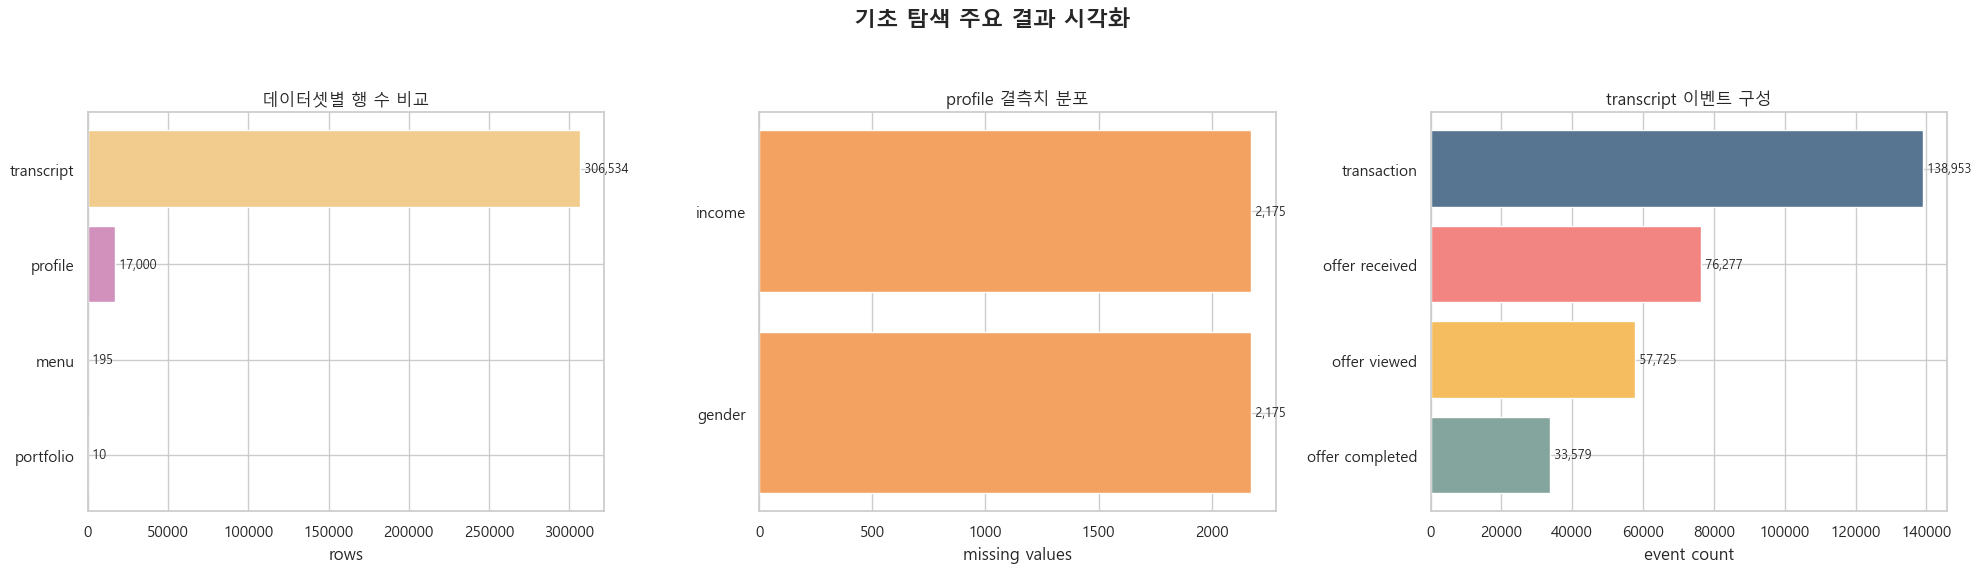

In [ ]:
import matplotlib.pyplot as plt

plt.rcParams["font.family"] = "Malgun Gothic"
plt.rcParams["axes.unicode_minus"] = False

size_overview = pd.DataFrame(
    [
        {"dataset": "portfolio", "rows": portfolio.shape[0]},
        {"dataset": "profile", "rows": profile.shape[0]},
        {"dataset": "transcript", "rows": transcript.shape[0]},
        {"dataset": "menu", "rows": menu.shape[0]},
    ]
).sort_values("rows", ascending=True)

profile_missing = (
    profile.isna()
    .sum()
    .rename_axis("column")
    .reset_index(name="missing_count")
    .query("missing_count > 0")
    .sort_values("missing_count", ascending=True)
)

event_counts = (
    transcript["event"]
    .value_counts()
    .rename_axis("event")
    .reset_index(name="count")
    .sort_values("count", ascending=True)
)
# transcript 이벤트 개수 집계
# offer received
# offer viewed
# offer completed
# transaction


fig, axes = plt.subplots(1, 3, figsize=(20, 5.5))
fig.suptitle("기초 탐색 주요 결과 시각화", fontsize=16, fontweight="bold", y=1.04)

size_colors = ["#7DB9B6", "#A2C5AC", "#D291BC", "#F2CC8F"]
axes[0].barh(size_overview["dataset"], size_overview["rows"], color=size_colors)
axes[0].set_title("데이터셋별 행 수 비교")
axes[0].set_xlabel("rows")
axes[0].set_ylabel("")
for index, value in enumerate(size_overview["rows"]):
    axes[0].text(value, index, f" {value:,}", va="center", fontsize=9)

missing_colors = ["#F4A261"] * len(profile_missing)
axes[1].barh(profile_missing["column"], profile_missing["missing_count"], color=missing_colors)
axes[1].set_title("profile 결측치 분포")
axes[1].set_xlabel("missing values")
axes[1].set_ylabel("")
for index, value in enumerate(profile_missing["missing_count"]):
    axes[1].text(value, index, f" {value:,}", va="center", fontsize=9)

event_colors = ["#84A59D", "#F6BD60", "#F28482", "#577590"]
axes[2].barh(event_counts["event"], event_counts["count"], color=event_colors)
axes[2].set_title("transcript 이벤트 구성")
axes[2].set_xlabel("event count")
axes[2].set_ylabel("")
for index, value in enumerate(event_counts["count"]):
    axes[2].text(value, index, f" {value:,}", va="center", fontsize=9)

plt.tight_layout()
plt.show()

## 3. 기초 탐색 결과 정리

이번 단계에서는 각 데이터셋의 기본 구조, 결측치, 컬럼 상태, 그리고 `transcript`의 `value` 컬럼 구조를 확인했습니다.

### 1) 데이터셋 구조 확인 결과
- 네 개의 데이터셋 모두 정상적으로 로드되어 분석 가능한 상태입니다.
- 모든 데이터셋에 `Unnamed: 0` 컬럼이 포함되어 있어, 이는 전처리 단계에서 제거 후보로 볼 수 있습니다.
- 데이터 규모 기준으로 보면:
  - `transcript`가 **306,534행**으로 가장 크며, 실제 고객 행동 로그 분석의 중심 테이블입니다.
  - `profile`은 고객 속성 정보, `portfolio`는 프로모션 메타정보, `menu`는 보조적인 제품 정보 테이블로 볼 수 있습니다.

### 2) 결측치 확인 결과
- `portfolio`, `transcript`, `menu`에는 결측치가 없습니다.
- `profile`에는 결측치가 존재합니다.
  - `gender`: **2,175건** 결측
  - `income`: **2,175건** 결측
- 따라서 고객 세그먼트 분석 시 `gender`와 `income`을 사용할 경우, 결측치 처리 기준을 먼저 정의해야 합니다.

### 3) 타입 및 전처리 관점에서의 확인 사항
- `portfolio`와 `transcript`의 핵심 컬럼은 현재 구조상 바로 분석 가능하지만, 일부 문자열 기반 컬럼은 후속 전처리가 필요합니다.
- `menu` 데이터는 영양 정보 컬럼 다수가 문자열 타입으로 들어와 있어, 수치 분석이 필요하면 숫자형 변환이 필요합니다.
- `became_member_on`은 현재 정수형이므로, 가입 시점 분석 전에는 날짜형으로 변환하는 것이 적절합니다.

### 4) transcript의 value 구조 확인 결과
`transcript`의 `value` 컬럼은 이벤트별로 구조가 다르지만, 패턴 자체는 비교적 일관적입니다.

- `transaction` → `amount`
- `offer received` → `offer id`
- `offer viewed` → `offer id`
- `offer completed` → `offer_id`, `reward`

이 결과는 다음을 의미합니다.
- `value` 컬럼은 이벤트 종류에 따라 분기해서 파싱해야 합니다.
- 특히 `offer received`, `offer viewed`, `offer completed` 사이에 `offer id`와 `offer_id` 표기 차이가 있으므로, 전처리 시 하나의 공통 컬럼으로 통일해야 합니다.
- 이후 퍼널 분석을 위해서는 `offer_id`, `reward`, `amount` 등을 별도 컬럼으로 추출하는 작업이 필요합니다.

### 5) 이번 단계의 결론
이번 탐색을 통해, 본격적인 분석 전에 다음 전처리가 필요하다는 점을 확인했습니다.

1. `Unnamed: 0` 컬럼 제거
2. `profile`의 결측치 처리 기준 정의
3. `became_member_on` 날짜형 변환
4. `transcript.value` 딕셔너리 파싱 및 주요 키 분리
5. `offer id` / `offer_id` 컬럼명 통일

다음 단계에서는 `transcript.value`를 실제 컬럼으로 분리해 이벤트 로그를 분석 가능한 테이블 형태로 변환하는 전처리를 진행하면 됩니다.

In [ ]:
portfolio_clean = portfolio.drop(columns=["Unnamed: 0"]).copy()
profile_clean = profile.drop(columns=["Unnamed: 0"]).copy()
transcript_clean = transcript.drop(columns=["Unnamed: 0"]).copy()
menu_clean = menu.drop(columns=["Unnamed: 0"]).copy()

profile_clean["became_member_on"] = pd.to_datetime(
    profile_clean["became_member_on"].astype(str),
    format="%Y%m%d",
    errors="coerce",
)

transcript_value_df = pd.json_normalize(transcript_value_parsed)

offer_id_from_received_viewed = transcript_value_df.get("offer id", pd.Series(pd.NA, index=transcript_value_df.index))
offer_id_from_completed = transcript_value_df.get("offer_id", pd.Series(pd.NA, index=transcript_value_df.index))

# 한 컬럼 안에 여러 정보가 딕셔너리처럼 들어 있음  ex : {'offer id': '9b98b8c7a33c4b65b9aebfe6a799e6d9'}
# 그래서 먼저 열로 펼쳐야 함
# 그래야 오퍼 ID를 기준으로 이벤트를 연결할 수 있음

transcript_value_df["offer_id"] = offer_id_from_received_viewed.combine_first(offer_id_from_completed)

transcript_value_df = transcript_value_df.drop(
    columns=[column for column in ["offer id"] if column in transcript_value_df.columns]
)

for column in ["reward", "amount"]:
    if column not in transcript_value_df.columns:
        transcript_value_df[column] = pd.NA

transcript_clean = pd.concat(
    [transcript_clean.reset_index(drop=True), transcript_value_df[["offer_id", "amount", "reward"]].reset_index(drop=True)],
    axis=1,
)

transcript_clean["offer_id"] = transcript_clean["offer_id"].astype("string")
transcript_clean["reward"] = pd.to_numeric(transcript_clean["reward"], errors="coerce")
transcript_clean["amount"] = pd.to_numeric(transcript_clean["amount"], errors="coerce")

clean_summary = pd.DataFrame(
    {
        "dataset": ["portfolio_clean", "profile_clean", "transcript_clean", "menu_clean"],
        "rows": [len(portfolio_clean), len(profile_clean), len(transcript_clean), len(menu_clean)],
        "columns": [portfolio_clean.shape[1], profile_clean.shape[1], transcript_clean.shape[1], menu_clean.shape[1]],
    }
)

transcript_event_summary = (
    transcript_clean.groupby("event")
    .agg(
        rows=("event", "size"),
        offer_id_non_null=("offer_id", lambda values: values.notna().sum()),
        reward_non_null=("reward", lambda values: values.notna().sum()),
        amount_non_null=("amount", lambda values: values.notna().sum()),
    )
    .reset_index()
    .sort_values("rows", ascending=False)
)

print("[clean dataset summary]")
display(clean_summary)

print("\n[transcript cleaned sample]")
display(transcript_clean.head(5))

print("\n[transcript event summary after parsing]")
display(transcript_event_summary)

print("\n[profile cleaned sample]")
display(profile_clean.head(5))

[clean dataset summary]


,dataset,rows,columns
0,portfolio_clean,10,6
1,profile_clean,17000,5
2,transcript_clean,306534,7
3,menu_clean,195,12



[transcript cleaned sample]


,person,event,value,time,offer_id,amount,reward
0,78afa995795e4d85b5d9ceeca43f5fef,offer received,{'offer id': '9b98b8c7a33c4b65b9aebfe6a799e6d9'},0,9b98b8c7a33c4b65b9aebfe6a799e6d9,NaN,NaN
1,a03223e636434f42ac4c3df47e8bac43,offer received,{'offer id': '0b1e1539f2cc45b7b9fa7c272da2e1d7'},0,0b1e1539f2cc45b7b9fa7c272da2e1d7,NaN,NaN
2,e2127556f4f64592b11af22de27a7932,offer received,{'offer id': '2906b810c7d4411798c6938adc9daaa5'},0,2906b810c7d4411798c6938adc9daaa5,NaN,NaN
3,8ec6ce2a7e7949b1bf142def7d0e0586,offer received,{'offer id': 'fafdcd668e3743c1bb461111dcafc2a4'},0,fafdcd668e3743c1bb461111dcafc2a4,NaN,NaN
4,68617ca6246f4fbc85e91a2a49552598,offer received,{'offer id': '4d5c57ea9a6940dd891ad53e9dbe8da0'},0,4d5c57ea9a6940dd891ad53e9dbe8da0,NaN,NaN



[transcript event summary after parsing]


,event,rows,offer_id_non_null,reward_non_null,amount_non_null
3,transaction,138953,0,0,138953
1,offer received,76277,76277,0,0
2,offer viewed,57725,57725,0,0
0,offer completed,33579,33579,33579,0



[profile cleaned sample]


,gender,age,id,became_member_on,income
0,NaN,118,68be06ca386d4c31939f3a4f0e3dd783,2017-02-12,NaN
1,F,55,0610b486422d4921ae7d2bf64640c50b,2017-07-15,112000.0
2,NaN,118,38fe809add3b4fcf9315a9694bb96ff5,2018-07-12,NaN
3,F,75,78afa995795e4d85b5d9ceeca43f5fef,2017-05-09,100000.0
4,NaN,118,a03223e636434f42ac4c3df47e8bac43,2017-08-04,NaN


## 5. 분석 목적 재정의

이번 단계부터 노트북의 중심 질문을 아래처럼 다시 정의합니다.

- 메인 질문: **어떤 오퍼가 더 잘 확인되고 완료되는가?**
- 메인 KPI: `view_rate = viewed / received`, `complete_rate = completed / viewed`, `final_complete_rate = completed / received`
- 핵심 해석 단위: **purchase conversion이 아니라 offer completion funnel**
- 보조 질문: **오퍼 진행 과정에서 거래 발생 패턴은 어떻게 관찰되는가?**

이번 노트북에서는 `completed`를 오퍼 완료 이벤트로 해석하며, `transaction`과 혼용하지 않습니다.

즉, 아래 퍼널은 다음 흐름을 보여 주기 위한 것입니다.

1. 오퍼를 받았는가 (`received`)
2. 오퍼를 확인했는가 (`viewed`)
3. 오퍼를 완료했는가 (`completed`)

또한 이후 단계에서는 두 가지 완료율을 함께 비교합니다.

- **단순 완료율**: 오퍼 instance에 연결된 completed를 그대로 사용
- **유효기간 반영 완료율**: `received_time <= completed_time <= received_time + duration` 조건을 만족하는 completed만 인정

이렇게 해야 오퍼가 많이 완료된 것처럼 보이는 경우와, 실제 유효기간 안에서 완료된 경우를 분리해서 볼 수 있습니다.

In [7]:
import numpy as np

# 퍼널 분석에서는 received, viewed, completed 세 이벤트만 사용합니다.
# transaction은 메인 KPI가 아니라 뒤에서 참고 지표로만 확인합니다.
event_priority = {
    "offer received": 0,
    "offer viewed": 1,
    "offer completed": 2,
}

# 같은 고객이 같은 오퍼를 여러 번 받을 수 있으므로,
# person + offer_id 조합 안에서 시간순으로 정렬한 뒤 received가 나올 때마다
# 새로운 오퍼 instance를 하나씩 생성합니다.
offer_event_log = (
    transcript_clean[
        transcript_clean["event"].isin(event_priority)
        & transcript_clean["offer_id"].notna()
    ]
    .copy()
    .assign(event_order=lambda dataframe: dataframe["event"].map(event_priority))
    .sort_values(["person", "offer_id", "time", "event_order"])
    .reset_index(drop=True)
 )

instance_rows = []

for (person, offer_id), group in offer_event_log.groupby(["person", "offer_id"], sort=False):
    # received가 나올 때마다 새로운 오퍼 노출 instance를 만듭니다.
    offer_instances = []

    for row in group.itertuples(index=False):
        if row.event == "offer received":
            offer_instances.append(
                {
                    "person": person,
                    "offer_id": offer_id,
                    "time_received": row.time,
                    "viewed_times": [],
                    "completed_times": [],
                }
            )
            continue

        # received 없이 나온 viewed/completed는 분모가 되는 instance가 없으므로
        # 메인 퍼널 계산에는 포함하지 않습니다.
        if not offer_instances:
            continue

        current_instance = offer_instances[-1]

        if row.event == "offer viewed":
            current_instance["viewed_times"].append(row.time)
        elif row.event == "offer completed":
            current_instance["completed_times"].append(row.time)

    for instance_number, instance in enumerate(offer_instances, start=1):
        first_view_time = min(instance["viewed_times"]) if instance["viewed_times"] else pd.NA
        first_completed_time = min(instance["completed_times"]) if instance["completed_times"] else pd.NA

        # complete_rate와 final_complete_rate는 received -> viewed -> completed 흐름을 보여주기 위해
        # viewed 이후에 발생한 completed만 funnel completed로 인정합니다.
        completed_after_view_candidates = [
            completed_time
            for completed_time in instance["completed_times"]
            if pd.notna(first_view_time) and completed_time >= first_view_time
        ]
        first_funnel_completed_time = (
            min(completed_after_view_candidates)
            if completed_after_view_candidates
            else pd.NA
        )

        instance_rows.append(
            {
                "person": person,
                "offer_id": offer_id,
                "offer_instance_no": instance_number,
                "offer_instance_id": f"{person}_{offer_id}_{instance_number}",
                "time_received": instance["time_received"],
                "time_viewed": first_view_time,
                "time_completed_any": first_completed_time,
                "time_completed_funnel": first_funnel_completed_time,
            }
        )

offer_instance_base = pd.DataFrame(instance_rows).merge(
    portfolio_clean[["id", "offer_type", "duration", "difficulty", "reward"]].rename(
        columns={"id": "portfolio_offer_id", "reward": "portfolio_reward"}
    ),
    left_on="offer_id",
    right_on="portfolio_offer_id",
    how="left",
).drop(columns=["portfolio_offer_id"] )

offer_instance_base["viewed_flag"] = offer_instance_base["time_viewed"].notna()
offer_instance_base["completed_any_flag"] = offer_instance_base["time_completed_any"].notna()
offer_instance_base["completed_flag"] = offer_instance_base["time_completed_funnel"].notna()
offer_instance_base["offer_group"] = np.where(
    offer_instance_base["offer_type"].eq("informational"),
    "informational_reference",
    "completion_comparable",
)


def summarise_offer_funnel(dataframe, group_columns):
    """오퍼 퍼널 KPI를 계산하는 공통 함수입니다."""
    summary = (
        dataframe.groupby(group_columns, dropna=False)
        .agg(
            received_count=("offer_instance_id", "count"),
            viewed_count=("viewed_flag", "sum"),
            completed_count=("completed_flag", "sum"),
            completed_any_count=("completed_any_flag", "sum"),
        )
        .reset_index()
    )

    # 분모는 항상 received 또는 viewed 전체 건수를 유지합니다.
    # completed가 0이어도 행을 제거하지 않아야 완료율이 과대 계산되지 않습니다.
    summary["view_rate"] = (summary["viewed_count"] / summary["received_count"] * 100).round(2)
    summary["complete_rate"] = (
        summary["completed_count"].div(summary["viewed_count"].replace(0, np.nan)).fillna(0) * 100
    ).round(2)
    summary["final_complete_rate"] = (summary["completed_count"] / summary["received_count"] * 100).round(2)

    return summary

overall_funnel_kpi = summarise_offer_funnel(
    offer_instance_base.assign(scope="overall"),
    ["scope"],
)

offer_type_funnel_kpi = summarise_offer_funnel(
    offer_instance_base,
    ["offer_type", "offer_group"],
).sort_values("final_complete_rate", ascending=False)

offer_funnel_kpi = summarise_offer_funnel(
    offer_instance_base,
    ["offer_id", "offer_type", "offer_group", "duration"],
).sort_values(["offer_type", "final_complete_rate"], ascending=[True, False])

print("[overall funnel KPI]")
display(overall_funnel_kpi)

print("\n[offer type funnel KPI]")
display(offer_type_funnel_kpi)

print("\n[offer-level funnel KPI]")
display(offer_funnel_kpi)

[overall funnel KPI]


,scope,received_count,viewed_count,completed_count,completed_any_count,view_rate,complete_rate,final_complete_rate
0,overall,76277,57725,23282,33101,75.68,40.33,30.52



[offer type funnel KPI]


,offer_type,offer_group,received_count,viewed_count,completed_count,completed_any_count,view_rate,complete_rate,final_complete_rate
1,discount,completion_comparable,30543,21445,12341,17600,70.21,57.55,40.41
0,bogo,completion_comparable,30499,25449,10941,15501,83.44,42.99,35.87
2,informational,informational_reference,15235,10831,0,0,71.09,0.00,0.00



[offer-level funnel KPI]


,offer_id,offer_type,offer_group,duration,received_count,viewed_count,completed_count,completed_any_count,view_rate,complete_rate,final_complete_rate
8,f19421c1d4aa40978ebb69ca19b0e20d,bogo,completion_comparable,5,7571,7264,3514,4262,95.95,48.38,46.41
4,4d5c57ea9a6940dd891ad53e9dbe8da0,bogo,completion_comparable,5,7593,7298,2739,3301,96.11,37.53,36.07
7,ae264e3637204a6fb9bb56bc8210ddfd,bogo,completion_comparable,7,7658,6716,2582,3635,87.70,38.45,33.72
6,9b98b8c7a33c4b65b9aebfe6a799e6d9,bogo,completion_comparable,7,7677,4171,2106,4303,54.33,50.49,27.43
9,fafdcd668e3743c1bb461111dcafc2a4,discount,completion_comparable,10,7597,7327,4586,5230,96.45,62.59,60.37
1,2298d6c36e964ae4a3e7e9706d1fb8c2,discount,completion_comparable,7,7646,7337,4350,5102,95.96,59.29,56.89
2,2906b810c7d4411798c6938adc9daaa5,discount,completion_comparable,7,7632,4118,2102,3955,53.96,51.04,27.54
0,0b1e1539f2cc45b7b9fa7c272da2e1d7,discount,completion_comparable,10,7668,2663,1303,3313,34.73,48.93,16.99
3,3f207df678b143eea3cee63160fa8bed,informational,informational_reference,4,7617,4144,0,0,54.40,0.00,0.00
5,5a8bc65990b245e5a138643cd4eb9837,informational,informational_reference,3,7618,6687,0,0,87.78,0.00,0.00


## 6-1. 간단한 통계 검정 추가

퍼널 KPI를 수치로 비교하는 것에서 한 걸음 더 나아가, 차이가 **우연히 나온 수준인지** 간단히 확인합니다.

여기서는 해석이 쉬운 **두 집단 비율 차이 검정(two-proportion z-test)** 세 가지를 봅니다.

1. `bogo`와 `discount`의 **view_rate 차이**
2. `bogo`와 `discount`의 **final_complete_rate 차이**
3. `M`과 `F` 고객의 **final_complete_rate 차이**

기준은 보통 다음처럼 읽습니다.

- `p_value < 0.05` 이면: 우연이라고 보기 어려운 차이
- `p_value >= 0.05` 이면: 표본에서는 차이가 보여도 통계적으로는 뚜렷하지 않음

In [8]:
from math import erfc, sqrt


def two_proportion_ztest(success_a, total_a, success_b, total_b, label_a, label_b, metric_name):
    rate_a = success_a / total_a
    rate_b = success_b / total_b
    pooled_rate = (success_a + success_b) / (total_a + total_b)
    standard_error = sqrt(pooled_rate * (1 - pooled_rate) * ((1 / total_a) + (1 / total_b)))

    if standard_error == 0:
        z_score = np.nan
        p_value = np.nan
    else:
        z_score = (rate_a - rate_b) / standard_error
        p_value = erfc(abs(z_score) / sqrt(2))

    return {
        "test": metric_name,
        "group_a": label_a,
        "group_b": label_b,
        "success_a": int(success_a),
        "total_a": int(total_a),
        "rate_a": round(rate_a * 100, 2),
        "success_b": int(success_b),
        "total_b": int(total_b),
        "rate_b": round(rate_b * 100, 2),
        "rate_gap_pctp": round((rate_a - rate_b) * 100, 2),
        "z_score": round(z_score, 3) if pd.notna(z_score) else np.nan,
        "p_value": round(p_value, 6) if pd.notna(p_value) else np.nan,
        "significant_at_5pct": bool(p_value < 0.05) if pd.notna(p_value) else False,
    }


comparable_offer_instances = offer_instance_base[
    offer_instance_base["offer_group"] == "completion_comparable"
].copy()

bogo_instances = comparable_offer_instances[
    comparable_offer_instances["offer_type"] == "bogo"
]
discount_instances = comparable_offer_instances[
    comparable_offer_instances["offer_type"] == "discount"
]

gender_offer_instances = comparable_offer_instances.merge(
    profile_clean[["id", "gender"]],
    left_on="person",
    right_on="id",
    how="left",
)

gender_offer_instances = gender_offer_instances[
    gender_offer_instances["gender"].isin(["M", "F"])
].copy()

male_instances = gender_offer_instances[gender_offer_instances["gender"] == "M"]
female_instances = gender_offer_instances[gender_offer_instances["gender"] == "F"]

hypothesis_tests = pd.DataFrame(
    [
        two_proportion_ztest(
            success_a=bogo_instances["viewed_flag"].sum(),
            total_a=len(bogo_instances),
            success_b=discount_instances["viewed_flag"].sum(),
            total_b=len(discount_instances),
            label_a="bogo",
            label_b="discount",
            metric_name="view_rate: bogo vs discount",
        ),
        two_proportion_ztest(
            success_a=bogo_instances["completed_flag"].sum(),
            total_a=len(bogo_instances),
            success_b=discount_instances["completed_flag"].sum(),
            total_b=len(discount_instances),
            label_a="bogo",
            label_b="discount",
            metric_name="final_complete_rate: bogo vs discount",
        ),
        two_proportion_ztest(
            success_a=male_instances["completed_flag"].sum(),
            total_a=len(male_instances),
            success_b=female_instances["completed_flag"].sum(),
            total_b=len(female_instances),
            label_a="M",
            label_b="F",
            metric_name="final_complete_rate: M vs F",
        ),
    ]
)

print("[simple hypothesis tests]")
display(hypothesis_tests)

for row in hypothesis_tests.itertuples(index=False):
    significance_text = "유의함" if row.significant_at_5pct else "유의하지 않음"
    print(
        f"- {row.test}: {row.group_a} {row.rate_a:.2f}% vs {row.group_b} {row.rate_b:.2f}% "
        f"(차이 {row.rate_gap_pctp:+.2f}%p, p-value={row.p_value:.6f}) -> {significance_text}"
    )

[simple hypothesis tests]


,test,group_a,group_b,success_a,total_a,rate_a,success_b,total_b,rate_b,rate_gap_pctp,z_score,p_value,significant_at_5pct
0,view_rate: bogo vs discount,bogo,discount,25449,30499,83.44,21445,30543,70.21,13.23,38.731,0.0,True
1,final_complete_rate: bogo vs discount,bogo,discount,10941,30499,35.87,12341,30543,40.41,-4.53,-11.526,0.0,True
2,final_complete_rate: M vs F,M,F,11535,30562,37.74,10428,21918,47.58,-9.83,-22.523,0.0,True


- view_rate: bogo vs discount: bogo 83.44% vs discount 70.21% (차이 +13.23%p, p-value=0.000000) -> 유의함
- final_complete_rate: bogo vs discount: bogo 35.87% vs discount 40.41% (차이 -4.53%p, p-value=0.000000) -> 유의함
- final_complete_rate: M vs F: M 37.74% vs F 47.58% (차이 -9.83%p, p-value=0.000000) -> 유의함


## 6. 퍼널 KPI 계산 결과 읽는 방법

위 코드에서 만든 세 가지 KPI는 각각 역할이 다릅니다.

- `view_rate`: 받은 오퍼 중 실제로 확인된 비율
- `complete_rate`: 확인된 오퍼 중 최종 완료까지 이어진 비율
- `final_complete_rate`: 받은 오퍼 중 최종 완료까지 이어진 비율

여기서 `final_complete_rate`는 이 노트북의 핵심 지표이지만, **purchase conversion**으로 해석하지 않습니다.

이 값은 어디까지나 **offer completion funnel의 마지막 단계 비율**이며, 아래처럼 읽어야 합니다.

- 높을수록 해당 오퍼가 received 기준으로 더 자주 완료되었다
- 낮을수록 viewed 또는 completed 단계에서 더 많이 이탈했다
- 거래가 함께 관찰되더라도, 그것만으로 특정 오퍼가 구매를 직접 만들었다고 단정하지 않는다

또한 `informational` 오퍼는 completed 의미가 다르거나 존재하지 않을 수 있으므로, 이후 비교에서는 `bogo`, `discount`와 분리해서 해석합니다.

In [5]:
# duration은 일(day) 단위이므로, transcript의 time 단위(시간)와 맞추기 위해 24를 곱합니다.
offer_instance_duration = offer_instance_base.copy()
offer_instance_duration["duration_hours"] = offer_instance_duration["duration"] * 24
offer_instance_duration["offer_window_end"] = (
    offer_instance_duration["time_received"] + offer_instance_duration["duration_hours"]
)

# 단순 완료율은 기존 completed_flag를 그대로 사용합니다.
# duration 반영 완료율은 received_time <= completed_time <= received_time + duration 조건을 만족해야 합니다.
offer_instance_duration["completed_in_window_flag"] = (
    offer_instance_duration["completed_flag"]
    & offer_instance_duration["time_completed_funnel"].notna()
    & (offer_instance_duration["time_completed_funnel"] >= offer_instance_duration["time_received"] )
    & (offer_instance_duration["time_completed_funnel"] <= offer_instance_duration["offer_window_end"] )
)

offer_instance_duration["complete_in_window_rate_base"] = offer_instance_duration["completed_in_window_flag"].astype(int)


def summarise_duration_funnel(dataframe, group_columns):
    """단순 완료율과 duration 반영 완료율을 함께 계산합니다."""
    summary = (
        dataframe.groupby(group_columns, dropna=False)
        .agg(
            received_count=("offer_instance_id", "count"),
            viewed_count=("viewed_flag", "sum"),
            completed_count=("completed_flag", "sum"),
            completed_in_window_count=("completed_in_window_flag", "sum"),
        )
        .reset_index()
    )

    summary["view_rate"] = (summary["viewed_count"] / summary["received_count"] * 100).round(2)
    summary["complete_rate"] = (
        summary["completed_count"].div(summary["viewed_count"].replace(0, np.nan)).fillna(0) * 100
    ).round(2)
    summary["complete_rate_in_window"] = (
        summary["completed_in_window_count"].div(summary["viewed_count"].replace(0, np.nan)).fillna(0) * 100
    ).round(2)
    summary["final_complete_rate"] = (summary["completed_count"] / summary["received_count"] * 100).round(2)
    summary["final_complete_rate_in_window"] = (
        summary["completed_in_window_count"] / summary["received_count"] * 100
    ).round(2)
    summary["final_complete_rate_gap"] = (
        summary["final_complete_rate"] - summary["final_complete_rate_in_window"]
    ).round(2)

    return summary

overall_duration_kpi = summarise_duration_funnel(
    offer_instance_duration.assign(scope="overall"),
    ["scope"],
)

offer_type_duration_kpi = summarise_duration_funnel(
    offer_instance_duration,
    ["offer_type", "offer_group"],
).sort_values("final_complete_rate_gap", ascending=False)

offer_duration_kpi = summarise_duration_funnel(
    offer_instance_duration,
    ["offer_id", "offer_type", "offer_group", "duration"],
).sort_values("final_complete_rate_gap", ascending=False)

print("[overall duration-aware funnel KPI]")
display(overall_duration_kpi)

print("\n[offer type duration-aware KPI]")
display(offer_type_duration_kpi)

print("\n[offer-level duration-aware KPI]")
display(offer_duration_kpi)

[overall duration-aware funnel KPI]


,scope,received_count,viewed_count,completed_count,completed_in_window_count,view_rate,complete_rate,complete_rate_in_window,final_complete_rate,final_complete_rate_in_window,final_complete_rate_gap
0,overall,76277,57725,23282,23282,75.68,40.33,40.33,30.52,30.52,0.0



[offer type duration-aware KPI]


,offer_type,offer_group,received_count,viewed_count,completed_count,completed_in_window_count,view_rate,complete_rate,complete_rate_in_window,final_complete_rate,final_complete_rate_in_window,final_complete_rate_gap
0,bogo,completion_comparable,30499,25449,10941,10941,83.44,42.99,42.99,35.87,35.87,0.0
1,discount,completion_comparable,30543,21445,12341,12341,70.21,57.55,57.55,40.41,40.41,0.0
2,informational,informational_reference,15235,10831,0,0,71.09,0.00,0.00,0.00,0.00,0.0



[offer-level duration-aware KPI]


,offer_id,offer_type,offer_group,duration,received_count,viewed_count,completed_count,completed_in_window_count,view_rate,complete_rate,complete_rate_in_window,final_complete_rate,final_complete_rate_in_window,final_complete_rate_gap
0,0b1e1539f2cc45b7b9fa7c272da2e1d7,discount,completion_comparable,10,7668,2663,1303,1303,34.73,48.93,48.93,16.99,16.99,0.0
1,2298d6c36e964ae4a3e7e9706d1fb8c2,discount,completion_comparable,7,7646,7337,4350,4350,95.96,59.29,59.29,56.89,56.89,0.0
2,2906b810c7d4411798c6938adc9daaa5,discount,completion_comparable,7,7632,4118,2102,2102,53.96,51.04,51.04,27.54,27.54,0.0
3,3f207df678b143eea3cee63160fa8bed,informational,informational_reference,4,7617,4144,0,0,54.40,0.00,0.00,0.00,0.00,0.0
4,4d5c57ea9a6940dd891ad53e9dbe8da0,bogo,completion_comparable,5,7593,7298,2739,2739,96.11,37.53,37.53,36.07,36.07,0.0
5,5a8bc65990b245e5a138643cd4eb9837,informational,informational_reference,3,7618,6687,0,0,87.78,0.00,0.00,0.00,0.00,0.0
6,9b98b8c7a33c4b65b9aebfe6a799e6d9,bogo,completion_comparable,7,7677,4171,2106,2106,54.33,50.49,50.49,27.43,27.43,0.0
7,ae264e3637204a6fb9bb56bc8210ddfd,bogo,completion_comparable,7,7658,6716,2582,2582,87.70,38.45,38.45,33.72,33.72,0.0
8,f19421c1d4aa40978ebb69ca19b0e20d,bogo,completion_comparable,5,7571,7264,3514,3514,95.95,48.38,48.38,46.41,46.41,0.0
9,fafdcd668e3743c1bb461111dcafc2a4,discount,completion_comparable,10,7597,7327,4586,4586,96.45,62.59,62.59,60.37,60.37,0.0


## 7. duration 반영 완료율 비교

이 단계에서는 같은 오퍼에 대해 두 가지 완료율을 동시에 봅니다.

- `final_complete_rate`: 단순 오퍼 완료율 (`completed / received`)
- `final_complete_rate_in_window`: 유효기간을 반영한 오퍼 완료율
- `final_complete_rate_gap`: 위 두 값의 차이

중요한 점은 **duration 조건을 적용해도 분모인 received_count는 그대로 유지**된다는 것입니다.

즉, 유효기간 안에 completed가 없으면 그 instance를 제거하지 않고 `completed_in_window_flag = 0`으로 남깁니다.

이렇게 해야 오퍼별 완료율이 실제보다 높게 계산되는 문제를 막을 수 있습니다.

또한 이 비교는 다음 질문에 답하기 위한 것입니다.

1. 단순 완료율이 높아 보여도 실제 유효기간 안에서 완료된 비율은 어느 정도인가?
2. 어떤 오퍼가 duration 조건에 더 민감한가?
3. informational 오퍼를 completion KPI 비교에서 제외해야 하는 이유가 데이터에서 어떻게 보이는가?

In [8]:
# 메인 비교 대상은 completed 의미가 비교 가능한 bogo, discount 오퍼입니다.
comparable_offer_table = offer_duration_kpi[
    offer_duration_kpi["offer_group"] == "completion_comparable"
].copy()

informational_offer_table = offer_duration_kpi[
    offer_duration_kpi["offer_group"] == "informational_reference"
][[
    "offer_id",
    "offer_type",
    "duration",
    "received_count",
    "viewed_count",
    "view_rate",
]].copy()

offer_type_comparison_table = offer_type_duration_kpi.copy()

# transaction은 메인 완료율 KPI에서 제외합니다.
# 대신 received 이후 거래가 관찰되었는지, completed 전후 어느 구간에 거래가 더 모이는지만 참고용으로 봅니다.
transaction_events = transcript_clean.loc[
    transcript_clean["event"] == "transaction",
    ["person", "time", "amount"],
] .copy()

transaction_reference = offer_instance_duration[[
    "offer_instance_id",
    "person",
    "offer_id",
    "offer_type",
    "offer_group",
    "time_received",
    "time_completed_funnel",
    "offer_window_end",
]].merge(
    transaction_events,
    on="person",
    how="left",
)

# 비교 전에 시점 컬럼을 숫자로 맞춰 두면 결측값이 있어도 안전하게 조건식을 만들 수 있습니다.
transaction_reference["time_received"] = pd.to_numeric(
    transaction_reference["time_received"],
    errors="coerce",
)
transaction_reference["time_completed_funnel_numeric"] = pd.to_numeric(
    transaction_reference["time_completed_funnel"],
    errors="coerce",
)
transaction_reference["offer_window_end"] = pd.to_numeric(
    transaction_reference["offer_window_end"],
    errors="coerce",
)

transaction_reference["transaction_after_receive_in_window_flag"] = (
    transaction_reference["time"].notna()
    & (transaction_reference["time"] >= transaction_reference["time_received"])
    & (transaction_reference["time"] <= transaction_reference["offer_window_end"]) 
)
transaction_reference["transaction_before_completion_flag"] = (
    transaction_reference["time"].notna()
    & transaction_reference["time_completed_funnel_numeric"].notna()
    & (transaction_reference["time"] >= transaction_reference["time_received"])
    & (transaction_reference["time"] < transaction_reference["time_completed_funnel_numeric"]) 
)
transaction_reference["transaction_after_completion_flag"] = (
    transaction_reference["time"].notna()
    & transaction_reference["time_completed_funnel_numeric"].notna()
    & (transaction_reference["time"] >= transaction_reference["time_completed_funnel_numeric"]) 
)

# 한 오퍼 instance에 거래가 여러 건 있을 수 있으므로,
# 먼저 instance별로 boolean 플래그를 집계한 뒤 offer_type 기준으로 다시 요약합니다.
instance_transaction_flags = (
    transaction_reference.groupby([
        "offer_instance_id",
        "offer_type",
        "offer_group",
    ], dropna=False)
    .agg(
        transaction_after_receive_in_window_flag=("transaction_after_receive_in_window_flag", "max"),
        transaction_before_completion_flag=("transaction_before_completion_flag", "max"),
        transaction_after_completion_flag=("transaction_after_completion_flag", "max"),
        avg_transaction_amount=("amount", "mean"),
    )
    .reset_index()
 )

reference_transaction_patterns = (
    instance_transaction_flags.groupby(["offer_type", "offer_group"], dropna=False)
    .agg(
        offer_instances=("offer_instance_id", "count"),
        instances_with_transaction_after_receive=("transaction_after_receive_in_window_flag", "sum"),
        instances_with_transaction_before_completion=("transaction_before_completion_flag", "sum"),
        instances_with_transaction_after_completion=("transaction_after_completion_flag", "sum"),
        avg_transaction_amount=("avg_transaction_amount", "mean"),
    )
    .reset_index()
 )

reference_transaction_patterns["after_receive_transaction_rate"] = (
    reference_transaction_patterns["instances_with_transaction_after_receive"]
    / reference_transaction_patterns["offer_instances"]
    * 100
).round(2)

print("[comparable offer table]")
display(comparable_offer_table)

print("\n[offer type comparison table]")
display(offer_type_comparison_table)

print("\n[informational reference table]")
display(informational_offer_table)

print("\n[reference transaction patterns]")
display(reference_transaction_patterns)

[comparable offer table]


,offer_id,offer_type,offer_group,duration,received_count,viewed_count,completed_count,completed_in_window_count,view_rate,complete_rate,complete_rate_in_window,final_complete_rate,final_complete_rate_in_window,final_complete_rate_gap
0,0b1e1539f2cc45b7b9fa7c272da2e1d7,discount,completion_comparable,10,7668,2663,1303,1303,34.73,48.93,48.93,16.99,16.99,0.0
1,2298d6c36e964ae4a3e7e9706d1fb8c2,discount,completion_comparable,7,7646,7337,4350,4350,95.96,59.29,59.29,56.89,56.89,0.0
2,2906b810c7d4411798c6938adc9daaa5,discount,completion_comparable,7,7632,4118,2102,2102,53.96,51.04,51.04,27.54,27.54,0.0
4,4d5c57ea9a6940dd891ad53e9dbe8da0,bogo,completion_comparable,5,7593,7298,2739,2739,96.11,37.53,37.53,36.07,36.07,0.0
6,9b98b8c7a33c4b65b9aebfe6a799e6d9,bogo,completion_comparable,7,7677,4171,2106,2106,54.33,50.49,50.49,27.43,27.43,0.0
7,ae264e3637204a6fb9bb56bc8210ddfd,bogo,completion_comparable,7,7658,6716,2582,2582,87.70,38.45,38.45,33.72,33.72,0.0
8,f19421c1d4aa40978ebb69ca19b0e20d,bogo,completion_comparable,5,7571,7264,3514,3514,95.95,48.38,48.38,46.41,46.41,0.0
9,fafdcd668e3743c1bb461111dcafc2a4,discount,completion_comparable,10,7597,7327,4586,4586,96.45,62.59,62.59,60.37,60.37,0.0



[offer type comparison table]


,offer_type,offer_group,received_count,viewed_count,completed_count,completed_in_window_count,view_rate,complete_rate,complete_rate_in_window,final_complete_rate,final_complete_rate_in_window,final_complete_rate_gap
0,bogo,completion_comparable,30499,25449,10941,10941,83.44,42.99,42.99,35.87,35.87,0.0
1,discount,completion_comparable,30543,21445,12341,12341,70.21,57.55,57.55,40.41,40.41,0.0
2,informational,informational_reference,15235,10831,0,0,71.09,0.00,0.00,0.00,0.00,0.0



[informational reference table]


,offer_id,offer_type,duration,received_count,viewed_count,view_rate
3,3f207df678b143eea3cee63160fa8bed,informational,4,7617,4144,54.40
5,5a8bc65990b245e5a138643cd4eb9837,informational,3,7618,6687,87.78



[reference transaction patterns]


,offer_type,offer_group,offer_instances,instances_with_transaction_after_receive,instances_with_transaction_before_completion,instances_with_transaction_after_completion,avg_transaction_amount,after_receive_transaction_rate
0,bogo,completion_comparable,30499,24522,1595,10941,13.675914,80.40
1,discount,completion_comparable,30543,25947,4417,12341,13.636202,84.95
2,informational,informational_reference,15235,9483,0,0,13.782905,62.24


## 8. offer별 비교 테이블 해석

위 표는 다음 순서로 읽으면 됩니다.

- 먼저 `view_rate`로 오퍼가 얼마나 잘 확인되는지 봅니다.
- 다음으로 `complete_rate`로 확인된 오퍼가 얼마나 자주 완료되는지 봅니다.
- 마지막으로 `final_complete_rate`와 `final_complete_rate_in_window`를 비교해 duration 반영 전후 차이를 확인합니다.

여기서 중요한 비교 포인트는 아래와 같습니다.

1. **단순 final complete rate가 높은 오퍼**
2. **duration 반영 후에도 final complete rate가 유지되는 오퍼**
3. **두 지표 차이(`final_complete_rate_gap`)가 큰 오퍼**

`informational` 오퍼는 completed 의미가 다르므로, 표에서도 별도 reference 그룹으로 분리했습니다.

또한 transaction 표는 메인 KPI가 아니라 참고 자료입니다.

- 오퍼를 받은 뒤 거래가 함께 관찰되었는지
- 오퍼 완료 전후에 거래가 어떤 구간에 더 많이 모였는지

정도만 확인하며, 특정 오퍼가 거래를 직접 만들었다고 해석하지 않습니다.

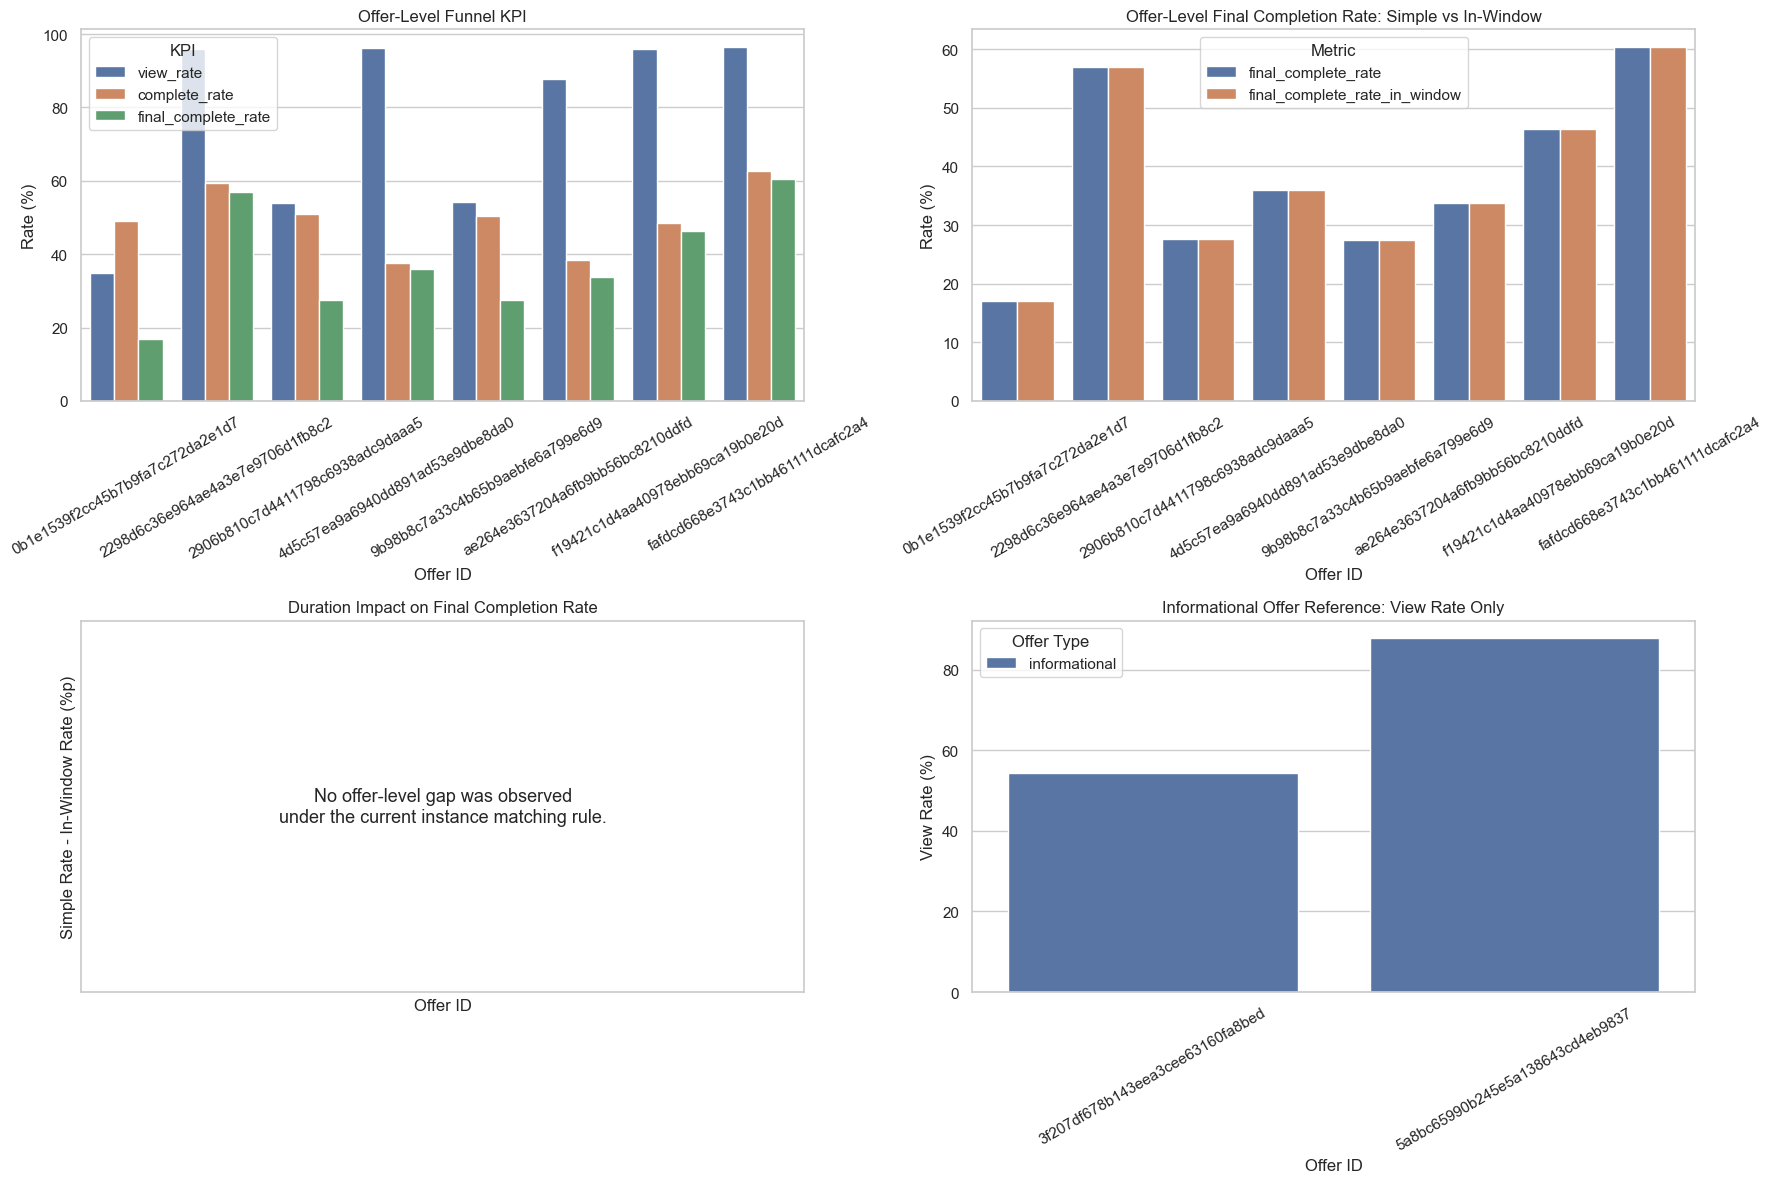

In [10]:
import matplotlib.pyplot as plt
import seaborn as sns

sns.set_theme(style="whitegrid")

plot_offer_rates = comparable_offer_table[[
    "offer_id",
    "offer_type",
    "view_rate",
    "complete_rate",
    "final_complete_rate",
]].melt(
    id_vars=["offer_id", "offer_type"],
    var_name="metric",
    value_name="rate",
)

plot_duration_comparison = comparable_offer_table[[
    "offer_id",
    "offer_type",
    "final_complete_rate",
    "final_complete_rate_in_window",
]].melt(
    id_vars=["offer_id", "offer_type"],
    var_name="metric",
    value_name="rate",
)

plot_gap = comparable_offer_table[[
    "offer_id",
    "offer_type",
    "final_complete_rate_gap",
]].copy()

plot_informational = informational_offer_table.copy()

fig, axes = plt.subplots(2, 2, figsize=(18, 12))

sns.barplot(
    data=plot_offer_rates,
    x="offer_id",
    y="rate",
    hue="metric",
    ax=axes[0, 0],
)
axes[0, 0].set_title("Offer-Level Funnel KPI")
axes[0, 0].set_xlabel("Offer ID")
axes[0, 0].set_ylabel("Rate (%)")
axes[0, 0].tick_params(axis="x", rotation=30)
axes[0, 0].legend(title="KPI")

sns.barplot(
    data=plot_duration_comparison,
    x="offer_id",
    y="rate",
    hue="metric",
    ax=axes[0, 1],
)
axes[0, 1].set_title("Offer-Level Final Completion Rate: Simple vs In-Window")
axes[0, 1].set_xlabel("Offer ID")
axes[0, 1].set_ylabel("Rate (%)")
axes[0, 1].tick_params(axis="x", rotation=30)
axes[0, 1].legend(title="Metric")

if plot_gap["final_complete_rate_gap"].abs().sum() == 0:
    axes[1, 0].text(
        0.5,
        0.5,
        "No offer-level gap was observed\nunder the current instance matching rule.",
        ha="center",
        va="center",
        fontsize=13,
    )
    axes[1, 0].set_title("Duration Impact on Final Completion Rate")
    axes[1, 0].set_xlabel("Offer ID")
    axes[1, 0].set_ylabel("Simple Rate - In-Window Rate (%p)")
    axes[1, 0].set_xticks([])
    axes[1, 0].set_yticks([])
else:
    sns.barplot(
        data=plot_gap,
        x="offer_id",
        y="final_complete_rate_gap",
        hue="offer_type",
        dodge=False,
        ax=axes[1, 0],
    )
    axes[1, 0].set_title("Duration Impact on Final Completion Rate")
    axes[1, 0].set_xlabel("Offer ID")
    axes[1, 0].set_ylabel("Simple Rate - In-Window Rate (%p)")
    axes[1, 0].tick_params(axis="x", rotation=30)
    axes[1, 0].legend(title="Offer Type")

sns.barplot(
    data=plot_informational,
    x="offer_id",
    y="view_rate",
    hue="offer_type",
    dodge=False,
    ax=axes[1, 1],
)
axes[1, 1].set_title("Informational Offer Reference: View Rate Only")
axes[1, 1].set_xlabel("Offer ID")
axes[1, 1].set_ylabel("View Rate (%)")
axes[1, 1].tick_params(axis="x", rotation=30)
axes[1, 1].legend(title="Offer Type")

plt.tight_layout()
plt.show()

## 9. 핵심 해석 요약

이번 노트북의 핵심 결론은 **구매 전환율**이 아니라 **오퍼 완료율 중심 퍼널**로 읽어야 합니다.

### 이번 실행 결과에서 확인된 메인 KPI

- 전체 `view_rate`는 **75.68%**였습니다.
- 전체 `complete_rate`는 **40.33%**였습니다.
- 전체 `final_complete_rate`는 **30.52%**였습니다.

즉, 이 노트북의 핵심 해석은 **received 기준으로 얼마나 많은 오퍼가 최종 완료까지 이어졌는가**입니다.

### offer type 기준 해석

- `discount`의 `final_complete_rate`는 **40.41%**로, `bogo`의 **35.87%**보다 높았습니다.
- `bogo`의 `view_rate`는 **83.44%**로, `discount`의 **70.21%**보다 높았습니다.
- 따라서 현재 결과에서는 `bogo`가 더 잘 확인되었고, `discount`가 더 자주 완료되었습니다.

### duration 반영 해석

- 현재 instance 매칭 기준에서는 `final_complete_rate`와 `final_complete_rate_in_window` 차이가 모든 comparable offer에서 **0.00%p**였습니다.
- 즉, 이번 매칭 규칙 아래에서는 순차적으로 연결된 completed가 모두 각 오퍼의 유효기간 안에서 관찰되었습니다.
- 따라서 이번 데이터에서는 duration 필터가 완료율을 추가로 낮추지 않았습니다.

### informational 오퍼 해석

- `informational`은 완료율 비교 대상이 아니라 reference 그룹으로 분리했습니다.
- 두 informational offer의 `view_rate`는 각각 **54.40%**, **87.78%**였습니다.
- 즉, informational은 완료율보다 **얼마나 확인되었는가** 중심으로 읽는 것이 적절합니다.

### transaction 해석

- transaction은 메인 완료율 KPI에서 제외했습니다.
- 참고 지표로 보면, received 이후 거래가 함께 관찰된 instance 비율은 `discount` **84.95%**, `bogo` **80.40%**, `informational` **62.24%**였습니다.
- 이 수치는 오퍼 진행 과정에서 거래가 함께 관찰된 정도를 보여 줄 뿐이며, 특정 오퍼 효과를 직접 증명하는 값은 아닙니다.